# Data Preparation

The rest of this page depends on the successful loading of the CSV data into df. Therefore, whenever you open or reconnect to this page, it is important to always **run this code block first** before working on the other code blocks of the page.

In [1]:
import pandas as pd
# set float display format to comma as thousand separator and 2 digits after the decimal point
pd.options.display.float_format = '{:,.2f}'.format

df = pd.read_csv('https://raw.githubusercontent.com/qarnac/cs201/refs/heads/main/insured_by_states_18_64.csv')
df.columns

# I created this dataset using HDPulse data under Healthcare System -> Insurance
# The data shows how many people aged 18 - 64 were insured in 2023
# It is critical to run this block first before running any of the following code blocks. Otherwise, data will not be ready in df.

Index(['State', 'All_Percent', 'All_People', 'White_Percent', 'White_People',
       'Black_Percent', 'Black_People', 'AI_AN_Percent', 'AI_AN_People',
       'API_Percent', 'API_People', 'Hispanic_Percent', 'Hispanic_People'],
      dtype='object')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             51 non-null     object 
 1   All_Percent       51 non-null     float64
 2   All_People        51 non-null     int64  
 3   White_Percent     51 non-null     float64
 4   White_People      51 non-null     int64  
 5   Black_Percent     51 non-null     float64
 6   Black_People      51 non-null     int64  
 7   AI_AN_Percent     51 non-null     float64
 8   AI_AN_People      51 non-null     int64  
 9   API_Percent       51 non-null     float64
 10  API_People        51 non-null     int64  
 11  Hispanic_Percent  51 non-null     float64
 12  Hispanic_People   51 non-null     int64  
dtypes: float64(6), int64(6), object(1)
memory usage: 5.3+ KB


# Data wrangling

The original dataset contains 13 columns. But not all 13 columns are needed to answer every question we have on insurance coverage. The following code block creates a new DataFrame to focus on insurance coverage for all races combined.

In [3]:
all_races_columns = ['State', 'All_Percent', 'All_People']
all_races_df = df[all_races_columns].copy()
all_races_df.head(3)

,State,All_Percent,All_People
0,Alabama,87.30,2551999
1,Alaska,85.30,371125
2,Arizona,86.20,3690186


Since we are now focusing on the data for all races combined, the extra prefix 'All_' in the column names are redundant. The following code block rename the columns to remove the extra prefix.

In [4]:
name_map = {'All_Percent': 'Percentage', 'All_People': 'Number'}
all_races_df = all_races_df.rename(columns=name_map)
all_races_df.head(3)

,State,Percentage,Number
0,Alabama,87.30,2551999
1,Alaska,85.30,371125
2,Arizona,86.20,3690186


We can also use the existing columns to create new columns. The following code block shows how to create a new column to show the population of the states.

In [5]:
all_races_df['Population'] = all_races_df['Number'] / all_races_df['Percentage'] * 100
all_races_df.head(6)

,State,Percentage,Number,Population
0,Alabama,87.30,2551999,"2,923,252.00"
1,Alaska,85.30,371125,"435,082.06"
2,Arizona,86.20,3690186,"4,280,958.24"
3,Arkansas,87.70,1535328,"1,750,659.06"
4,California,91.00,21646886,"23,787,786.81"
5,Colorado,90.80,3320582,"3,657,028.63"


In [6]:
all_races_df.describe()

,Percentage,Number,Population
count,51.00,51.00,51.00
mean,89.90,"3,447,982.47","3,874,907.59"
std,3.77,"3,915,733.08","4,479,679.08"
min,78.40,"282,570.00","334,798.58"
25%,87.15,"950,184.50","1,067,096.95"
50%,91.00,"2,344,505.00","2,599,546.67"
75%,92.65,"4,216,251.00","4,538,335.32"
max,96.50,"21,646,886.00","23,787,786.81"


The following code block labels the states based on its population

In [7]:
size_bins = [0, 3000000, 15000000, 30000000]
size_labels=['Small', 'Medium', 'Large']
all_races_df['State_Size'] = pd.cut(all_races_df['Population'], bins=size_bins, labels=size_labels)
all_races_df.head(5)

,State,Percentage,Number,Population,State_Size
0,Alabama,87.30,2551999,"2,923,252.00",Small
1,Alaska,85.30,371125,"435,082.06",Small
2,Arizona,86.20,3690186,"4,280,958.24",Medium
3,Arkansas,87.70,1535328,"1,750,659.06",Small
4,California,91.00,21646886,"23,787,786.81",Large


## Practice

Complete the following tasks. You may use as many or as few code blocks as you'd like.

* Create a DataFrame object to focus on the insurance coverage for one race of your choice
* Rename the columns to remove unnecessary prefix
* Create a new column to hold the total number of people for the race
* Create a new column to label the states using low, medium, and high based on the insurance coverage of your choice.

# Histograms

A **histogram** is a graph that shows how many values fall into different ranges (called bins). Let's look at a few examples to understand how histograms help show data distributions.

The `plot` function we used for bar charts can also be used to create a histogram as shown in the following code block.

*  We only need to identify the column for the y-axis.
*  There is no column for the x axis. By default, the `plot` function divides up the range of the numeric column into 10 equal smaller ranges (bins). Since the highest percent for all races is 96.50 and the lowest is 78.40, the overall range is 18.10. One-tenth of the range is 1.81 and the bins have the following ranges,

    *  Frst bin: 78.40 to 80.21
    *  Second bin: 80.21 to 82.02
    *  And so on so forth
*  The height of each bar tells how many states fall into the range for that bin. In this way, a histogram can help us see patterns:
    *  Is it symmetric, left-skewed, right-skewed, bimodal…?
    *  Are there outliers?

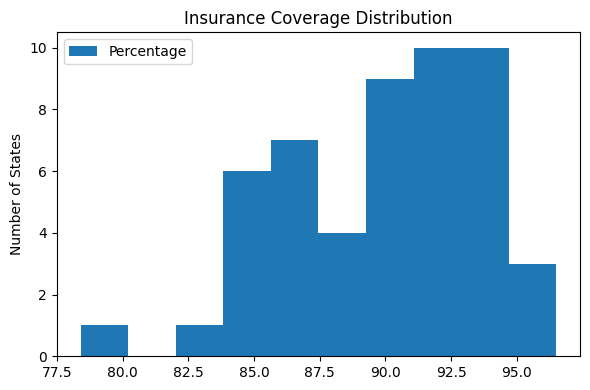

In [8]:
import matplotlib.pyplot as plt     # import appropriate library

# create the bar chart
all_races_df.plot(kind='hist', y='Percentage',
                  figsize=(6, 4),
                  title='Insurance Coverage Distribution',
                  ylabel='Number of States'
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

The above histogram shows the following
*  Only one state has coverage percentage below 80.21, possibly an outlier compared to other states.
*  There are 6 states whose coverage percentage belong to the fourth bin (83.83 to 85.64), 7 states for the fifth bin (85.64 to 87.45), etc.
*  The distribution is right skewed, i.e. heavier on the bins for larger percentages.

There are additional parameters for the plot function we can adjust.
*  The `bins` parameter specifies the number of bins to be used.
*  The `range` parameter specifies the lower and upper bounds of the bins.
*  The `color` parameter specifies the color of the bars.
*  The `edgecolor` parameter specifies the color of the edges for the bars.
*  The `alpha` parameter specifies the level of transparency for the bars. 0 is fully transparent and 1 is fully opaque.
*  The `legend` parameter indicates whether to show the legend of the graph.


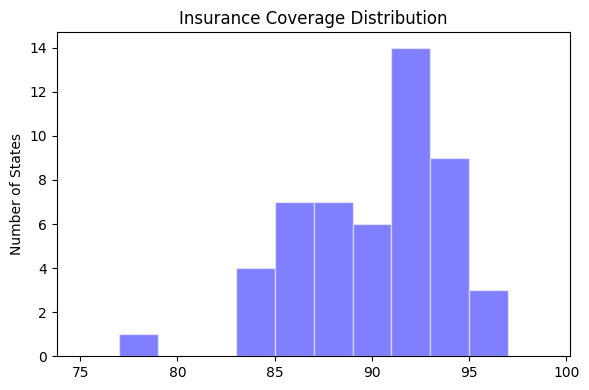

In [9]:
import matplotlib.pyplot as plt     # import appropriate library

# create the bar chart
all_races_df.plot(kind='hist', y='Percentage',
                  figsize=(6, 4),
                  title='Insurance Coverage Distribution',
                  ylabel='Number of States',
                  bins=12,
                  range=(75, 99),
                  color='blue',
                  edgecolor='white',
                  alpha=0.5,
                  legend=False
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

The following code block shows the distribution of coverage for states whose number of people insured are between 1 and 10 million.

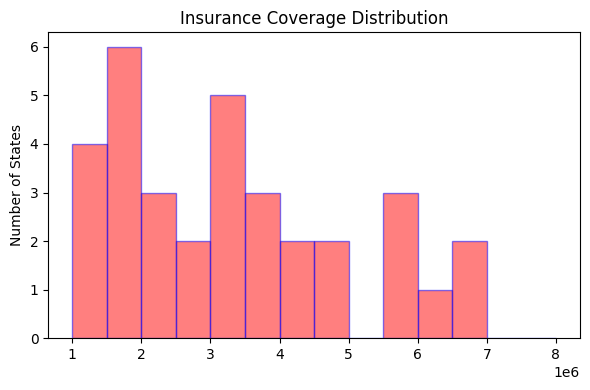

In [13]:
import matplotlib.pyplot as plt     # import appropriate library

# create the bar chart
all_races_df.plot(kind='hist', y='Number',
                  figsize=(6, 4),
                  title='Insurance Coverage Distribution',
                  ylabel='Number of States',
                  bins=14,
                  range=(1000000, 8000000),
                  color='red',
                  edgecolor='blue',
                  alpha=0.5,
                  legend=False
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

The above histograph shows that there are
*  4 states whose insurance coverage for all races are between 1 and 1.5 million, including 1 million but excluding 1.5 million.
*  6 states whose insurance coverage for all races are between 1.5 and 2 million, including 1.5 million but excluding 2 million.
*  3 states for between 2 and 2.5, etc.

The bins for these histograms are left inclusive and right exclusive.

## Practice

In [11]:
# Create a histogram for the percentage coverage for the race of your choice


In [12]:
# Create a histogram for the population for the race of your choice


Add a text block to explain what you learn about the insurance coverage and population for the race of your choice through the above histogram.